In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import browse_swot_2km, add_grid_metrics
from diagnosis import (
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_mean_square,
    compute_mean_square_groupby,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# Gaussian v0 :
- 2 convolved with mask renormalization
- swot_image fill with 0
- inter fauchée non interpolée

In [73]:
# Stencil method
def apply_stencil_diff(image, var, dx, dy):
    from scipy.ndimage import convolve

    assert var in [
        "dx",
        "dy",
        "dxx",
        "dyy",
        "dxy",
    ], "var must be in 'dx', 'dy', 'dxx', 'dyy', 'dxy'"

    stx = np.array(
        [[1 / 280, -4 / 105, 1 / 5, 4 / 5, 0, -4 / 5, -1 / 5, 4 / 105, -1 / 280]]
    )
    sty = stx.T
    norm = -sum(
        np.arange(0, 9)
        * [1 / 280, -4 / 105, 1 / 5, 4 / 5, 0, -4 / 5, -1 / 5, 4 / 105, -1 / 280]
    )

    if var == "dx":
        output = convolve(image, stx, mode="mirror") / dx / norm
    if var == "dy":
        output = convolve(image, sty, mode="mirror") / dy / norm
    if var == "dxx":
        output = (
            convolve(convolve(image, stx, mode="mirror"), stx) / dx / dx / (norm**2)
        )
    if var == "dyy":
        output = (
            convolve(convolve(image, sty, mode="mirror"), sty) / dy / dy / (norm**2)
        )
    if var == "dxy":
        output = (
            convolve(convolve(image, stx, mode="mirror"), sty) / dy / dx / (norm**2)
        )

    return xr.DataArray(output, dims=image.dims)


# Fitting kernel
def fitting_coeff(image, var, dx, dy):
    """
    fitting method inspired from Tranchant
    input :
        var must be in 'cste', 'dx', 'dy', 'dxx', 'dyy', 'dxy'
    May be revised using Tranchant code : https://github.com/treden/SwotDiag/blob/main/SwotDiag/misc.py
    """
    # https://github.com/treden/SwotDiag/blob/main/SwotDiag/misc.py
    meaning_coeff = {"cste": 0, "dx": 1, "dy": 2, "dxx": 3, "dyy": 4, "dxy": 5}
    assert (
        var in meaning_coeff.keys()
    ), "var must be in 'cste', 'dx', 'dy', 'dxx', 'dyy', 'dxy'"
    n = int(np.sqrt(image.shape[0]))
    if isinstance(image, xr.DataArray):
        image = image.values
    x = np.arange(n)
    y = np.arange(n)
    X, Y = np.meshgrid(x, y, copy=False)
    X, Y = np.meshgrid(x, y, copy=False)

    X = X.flatten()
    Y = Y.flatten()

    A = np.array([X * 0 + 1, X, Y, X**2, Y**2, X * Y]).T

    coeff, r, rank, s = np.linalg.lstsq(A, image, rcond=-1)
    dxdy_diff = np.array([1, 1 / dx, 1 / dy, 1 / dx / dx, 1 / dy / dy, 1 / dy / dx]).T
    coeff = coeff * dxdy_diff

    return coeff[meaning_coeff[var]]


def apply_fitting_kernel(swot_image, var, npts, dx, dy):
    from scipy.ndimage import generic_filter

    assert npts % 2 == 1, "must be odd"
    return xr.DataArray(
        generic_filter(
            swot_image,
            fitting_coeff,
            size=[npts, npts],
            extra_keywords={"var": var, "dx": dx, "dy": dy},
        ),
        dims=swot_image.dims,
    )


# Gaussian
def apply_gaussian_filter(swot_image, cutoff, mask, dx, dy):
    from scipy.ndimage import convolve1d
    import scipy.signal.windows as wdw

    # Gaussian a la mano
    lambda_cutoff = cutoff / dx
    sigma_cutoff = lambda_cutoff * np.sqrt(np.log(2))
    Mg = int(2 * np.round(4 * lambda_cutoff) + 1)
    gaussian = wdw.gaussian(Mg, std=sigma_cutoff)
    fg = xr.DataArray(
        convolve1d(
            convolve1d(swot_image.fillna(0), gaussian, axis=0), gaussian, axis=1
        ),
        dims=swot_image.dims,
    )  # unnromalized
    fm = xr.DataArray(
        convolve1d(convolve1d(mask, gaussian, axis=0), gaussian, axis=1), dims=mask.dims
    )  # unnormalized
    return xr.DataArray(fg / fm, dims=swot_image.dims)  # normalized


# Wraper
def define_eta(ds, mean_sla):
    ds["etaf"] = (
        ds.duacs_ssha_karin_2_filtered
        + ds.cvl_mean_dynamic_topography_cnes_cls_22
        + ds.cvl_ocean_tide_fes_2022
    )
    ds["etac"] = (
        ds.duacs_ssha_karin_2_calibrated
        + ds.cvl_mean_dynamic_topography_cnes_cls_22
        + ds.cvl_ocean_tide_fes_2022
    )
    if mean_sla:
        dsm = xr.open_dataset(
            os.path.join(
                zarr_dir,
                "before_coloc",
                "preprocessed_swot",
                "swot2km",
                f"pass{int(ds.pass_number.mean().values)}_swot2km_meansla.nc",
            )
        )
        ds["etafm"] = ds.etaf - dsm.mean_slaf
        ds["etacm"] = ds.etac - dsm.mean_slac


def filter_diff_one(
    f,
    filter_diff_method="gaussian",
    filter_diff_kwargs={"cutoff": 5e3},
    mean_sla=False,
    distance_to_coast_max=None,
):
    ds = xr.open_dataset(f)
    define_eta(ds, mean_sla)
    ds = add_grid_metrics(ds)
    dx = float(ds.dx.mean())
    dy = float(ds.dy.mean())

    vars_ = [v for v in list(ds.keys()) if ("etaf" in v) | ("etac" in v)] + [
        "duacs_editing_flag",
        "longitude",
        "latitude",
    ]

    ds = ds.drop_vars(["latitude_nadir", "longitude_nadir", "dx", "phi", "dy"])[vars_]

    if filter_diff_method == "fitting_kernel":
        ds = ds.interpolate_na("num_pixels").interpolate_na(
            "num_lines"
        )  # erreur dans l'entre-fauchée pour gaussian filter but ok for fitting kernel
    mask = ds.duacs_editing_flag.where(ds.duacs_editing_flag != 0, 1).where(
        ds.duacs_editing_flag == 0, 0
    )
    try:
        D = []
        for eta in [v for v in list(ds.keys()) if ("etaf" in v) | ("etac" in v)]:
            swot_image = ds[eta]
            # gaussian method
            if filter_diff_method == "gaussian":
                assert list(filter_diff_kwargs.keys()) == [
                    "cutoff"
                ], "The gaussian method needs one argument cutoff (gaussian x at H/2)"
                output = (
                    apply_gaussian_filter(
                        swot_image, **filter_diff_kwargs, mask=mask, dx=dx, dy=dy
                    )
                    .rename("filtered_" + eta)
                    .to_dataset()
                )
                for var in ["dx", "dy", "dxx", "dyy", "dxy"]:
                    output[var + "_" + eta] = apply_stencil_diff(
                        output["filtered_" + eta], var, dx=dx, dy=dy
                    )
                D.append(output)

            # Fitting kernel method
            if filter_diff_method == "fitting_kernel":
                assert list(filter_diff_kwargs.keys()) == [
                    "npts"
                ], "The fitting kernel method needs one argument npts (odd, kernel = [npts, npts])"
                output = (
                    apply_fitting_kernel(
                        swot_image, **filter_diff_kwargs, var="cste", dx=dx, dy=dy
                    )
                    .rename("filtered_" + eta)
                    .to_dataset()
                )
                for var in ["dx", "dy", "dxx", "dyy", "dxy"]:
                    output[var + "_" + eta] = apply_fitting_kernel(
                        swot_image, **filter_diff_kwargs, var=var, dx=dx, dy=dy
                    )
                D.append(output)

            # diff only method
            if filter_diff_method == "diff_only":
                output = swot_image.rename(eta).to_dataset()
                for var in ["dx", "dy", "dxx", "dyy", "dxy"]:
                    output[var + "_" + eta] = apply_stencil_diff(
                        swot_image, var, dx=dx, dy=dy
                    )
                D.append(output)

            # xarray simple diff
            if filter_diff_method == "xarray_diff":
                output = swot_image.rename(eta).to_dataset()
                output["dx_" + eta] = output[eta].differentiate("num_pixels") / dx
                output["dy_" + eta] = output[eta].differentiate("num_lines") / dy
                output["dxx_" + eta] = (
                    output["dx_" + eta].differentiate("num_pixels") / dx
                )
                output["dyy_" + eta] = (
                    output["dy_" + eta].differentiate("num_lines") / dy
                )
                output["dxy_" + eta] = (
                    output["dx_" + eta].differentiate("num_lines") / dy
                )
                D.append(output)

    except:
        assert False, f
    return xr.merge(D + [ds[["longitude", "latitude"]]]).where(
        ds.duacs_editing_flag == 0
    )


def _concat(
    ds, filter_diff_method, filter_diff_kwargs, mean_sla, distance_to_coast_max
):
    D = []
    for f in ds.file.values:
        D.append(
            filter_diff_one(
                f,
                filter_diff_method,
                filter_diff_kwargs,
                mean_sla=mean_sla,
                distance_to_coast_max=distance_to_coast_max,
            )
        )
    try:
        xs = xr.concat(D, dim=ds.cycle_number)
    except:
        assert False, f
    return xs


def compute_filter_diff(
    ds, filter_diff_method, filter_diff_kwargs, mean_sla, distance_to_coast_max=None
):

    template = _concat(
        ds.isel(cycle_number=slice(0, 2)),
        filter_diff_method="gaussian",
        filter_diff_kwargs={"cutoff": 5e3},
        mean_sla=mean_sla,
        distance_to_coast_max=distance_to_coast_max,
    ).compute()
    template = (
        template.isel(cycle_number=0)
        .expand_dims({"cycle_number": ds.cycle_number})
        .chunk({**ds.chunks, **{"num_pixels": -1, "num_lines": -1}})
    )
    dims = ["cycle_number", "num_lines", "num_pixels"]
    template = template.transpose(*dims)

    # actually perform the calculation
    ds_diff = ds.map_blocks(
        _concat,
        kwargs=dict(
            filter_diff_method=filter_diff_method,
            filter_diff_kwargs=filter_diff_kwargs,
            mean_sla=mean_sla,
            distance_to_coast_max=distance_to_coast_max,
        ),
        template=template,
    )
    return ds_diff

In [81]:
# Gaussian
def apply_gaussian_filter(swot_image, cutoff, mask, dx, dy):
    import scipy.signal.windows as wdw

    # Gaussian a la mano
    from scipy.ndimage import convolve1d

    lambda_cutoff = cutoff / dx
    sigma_cutoff = lambda_cutoff * np.sqrt(np.log(2))
    Mg = int(2 * np.round(4 * lambda_cutoff) + 1)
    gaussian = wdw.gaussian(Mg, std=sigma_cutoff)
    fg = xr.DataArray(
        convolve1d(
            convolve1d(swot_image.fillna(0), gaussian, axis=0), gaussian, axis=1
        ),
        dims=swot_image.dims,
    )  # unnromalized
    fm = xr.DataArray(
        convolve1d(convolve1d(mask, gaussian, axis=0), gaussian, axis=1), dims=mask.dims
    )  # unnormalized
    return xr.DataArray(fg / fm, dims=swot_image.dims)  # normalized

    # Gaussian from
    # lambda_cutoff = cutoff/dx
    # sigma_cutoff = lambda_cutoff * np.sqrt(np.log(2))
    # from scipy.ndimage import gaussian_filter
    # fg = xr.DataArray(gaussian_filter(swot_image.fillna(np.mean(swot_image)), sigma = sigma_cutoff, axes=[0, 1]), dims=swot_image.dims)#unnromalized

    # return xr.DataArray(fg, dims=swot_image.dims)#normalized


def filter_diff_one(
    f,
    filter_diff_method="gaussian",
    filter_diff_kwargs={"cutoff": 5e3},
    mean_sla=False,
    distance_to_coast_max=20e3,
):
    ds = xr.open_dataset(f)
    define_eta(ds, mean_sla)
    ds = add_grid_metrics(ds)

    if distance_to_coast_max != None:
        ds = ds.where(ds.distance_to_coast > distance_to_coast_max, drop=True)

    dx = float(ds.dx.mean())
    dy = float(ds.dy.mean())

    vars_ = [v for v in list(ds.keys()) if ("etaf" in v) | ("etac" in v)] + [
        "duacs_editing_flag",
        "longitude",
        "latitude",
    ]

    ds = ds.drop_vars(["latitude_nadir", "longitude_nadir", "dx", "phi", "dy"])[vars_]

    if filter_diff_method == "fitting_kernel":
        ds = ds.interpolate_na("num_pixels").interpolate_na(
            "num_lines"
        )  # erreur dans l'entre-fauchée pour gaussian filter but ok for fitting kernel
    # ds = ds.interpolate_na('num_pixels').interpolate_na('num_lines') # erreur dans l'entre-fauchée pour gaussian filter but ok for fitting kernel

    mask = ds.duacs_editing_flag.where(ds.duacs_editing_flag != 0, 1).where(
        ds.duacs_editing_flag == 0, 0
    )
    try:
        D = []
        for eta in [v for v in list(ds.keys()) if ("etaf" in v) | ("etac" in v)]:
            swot_image = ds[eta]
            # gaussian method
            if filter_diff_method == "gaussian":
                assert list(filter_diff_kwargs.keys()) == [
                    "cutoff"
                ], "The gaussian method needs one argument cutoff (gaussian x at H/2)"
                output = (
                    apply_gaussian_filter(
                        swot_image, **filter_diff_kwargs, mask=mask, dx=dx, dy=dy
                    )
                    .rename("filtered_" + eta)
                    .to_dataset()
                )
                for var in ["dx", "dy", "dxx", "dyy", "dxy"]:
                    output[var + "_" + eta] = apply_stencil_diff(
                        output["filtered_" + eta], var, dx=dx, dy=dy
                    )
                D.append(output)

            # Fitting kernel method
            if filter_diff_method == "fitting_kernel":
                assert list(filter_diff_kwargs.keys()) == [
                    "npts"
                ], "The fitting kernel method needs one argument npts (odd, kernel = [npts, npts])"
                output = (
                    apply_fitting_kernel(
                        swot_image, **filter_diff_kwargs, var="cste", dx=dx, dy=dy
                    )
                    .rename("filtered_" + eta)
                    .to_dataset()
                )
                for var in ["dx", "dy", "dxx", "dyy", "dxy"]:
                    output[var + "_" + eta] = apply_fitting_kernel(
                        swot_image, **filter_diff_kwargs, var=var, dx=dx, dy=dy
                    )
                D.append(output)

            # diff only method
            if filter_diff_method == "diff_only":
                output = swot_image.rename(eta).to_dataset()
                for var in ["dx", "dy", "dxx", "dyy", "dxy"]:
                    output[var + "_" + eta] = apply_stencil_diff(
                        swot_image, var, dx=dx, dy=dy
                    )
                D.append(output)

            # xarray simple diff
            if filter_diff_method == "xarray_diff":
                output = swot_image.rename(eta).to_dataset()
                output["dx_" + eta] = output[eta].differentiate("num_pixels") / dx
                output["dy_" + eta] = output[eta].differentiate("num_lines") / dy
                output["dxx_" + eta] = (
                    output["dx_" + eta].differentiate("num_pixels") / dx
                )
                output["dyy_" + eta] = (
                    output["dy_" + eta].differentiate("num_lines") / dy
                )
                output["dxy_" + eta] = (
                    output["dx_" + eta].differentiate("num_lines") / dy
                )
                D.append(output)

    except:
        assert False, f
    return xr.merge(D + [ds[["longitude", "latitude"]]]).where(
        ds.duacs_editing_flag == 0
    )

# PB at the edge contaminate the whole Swath

In [86]:
product = "swot2km"
method = "gaussian"
Cutoff = np.arange(5e3, 56e3, 10e3)
if product == "swot2km":
    dfs = browse_swot_2km().reset_index()
DS = []
# Gaussian
from cstes import zarr_dir

for pass_ in [3]:
    df = dfs[dfs.pass_number == pass_]
    ds_swot = df.set_index("cycle_number").iloc[0:10].to_xarray().persist()
    for cutoff in Cutoff:
        C = compute_filter_diff(
            ds_swot,
            filter_diff_method=method,
            filter_diff_kwargs={"cutoff": cutoff},
            mean_sla=False,
            distance_to_coast_max=None,
        ).compute()
        C["pass_number"] = pass_
        C["cutoff"] = xr.DataArray([cutoff], dims="cutoff")
        C = C.set_coords("cutoff")
        DS.append(C)
ds = xr.concat(DS, dim="cutoff")

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

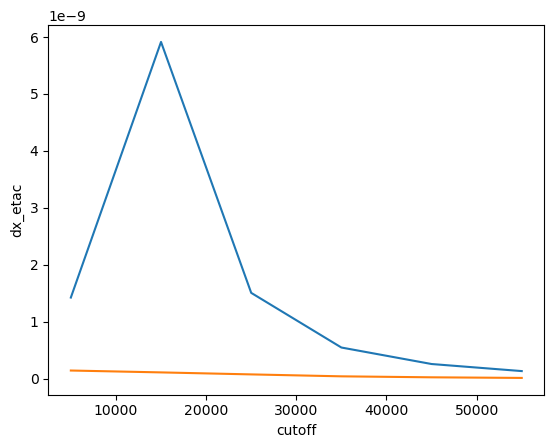

In [87]:
# ds.dx_etac.std(['cycle_number', 'num_lines', 'num_pixels']).plot()
(ds.dy_etac**2).mean(["cycle_number", "num_lines", "num_pixels"]).plot()
(ds.dx_etac**2).mean(["cycle_number", "num_lines", "num_pixels"]).plot()

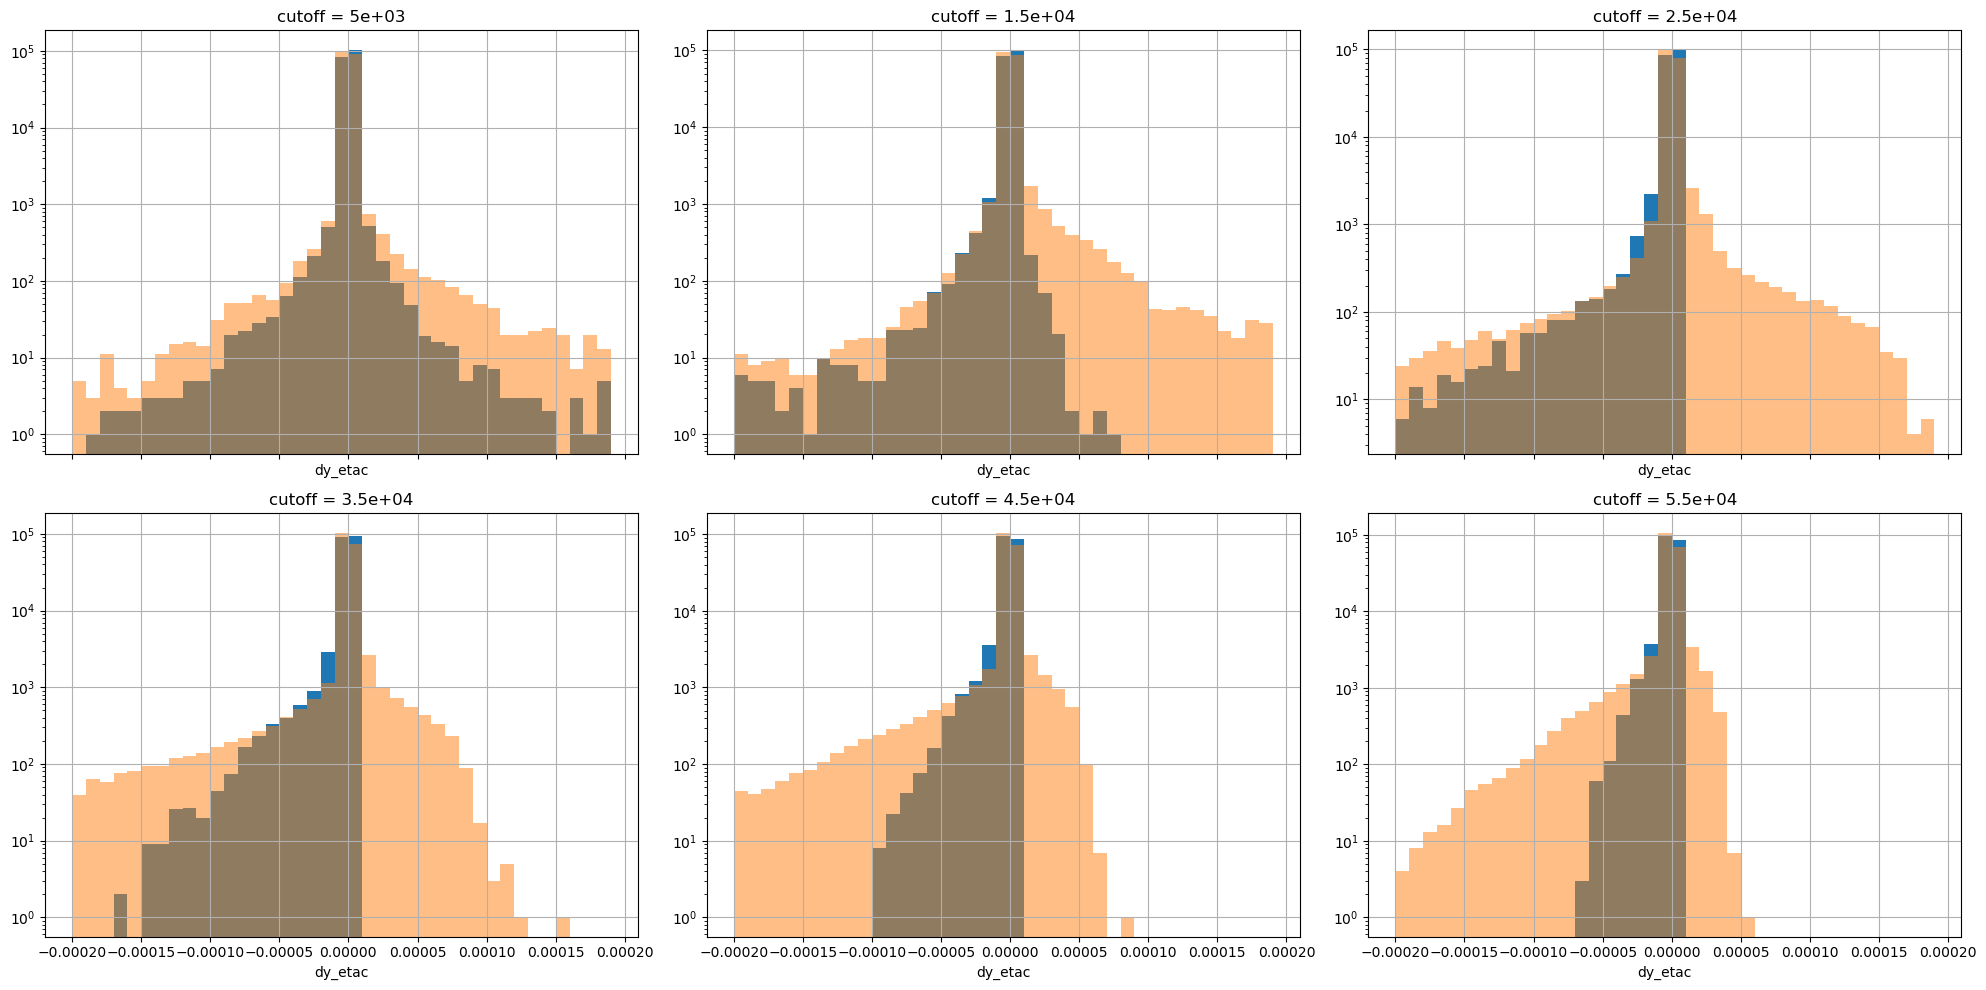

In [88]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for i in range(len(ds.cutoff)):
    ds.isel(cutoff=i).dx_etac.plot.hist(ax=axs[i], bins=np.arange(-2e-4, 2e-4, 1e-5))
    ds.isel(cutoff=i).dy_etac.plot.hist(
        ax=axs[i], bins=np.arange(-2e-4, 2e-4, 1e-5), alpha=0.5
    )
for ax in axs:
    ax.grid()
    ax.set_yscale("log")
fig.tight_layout()

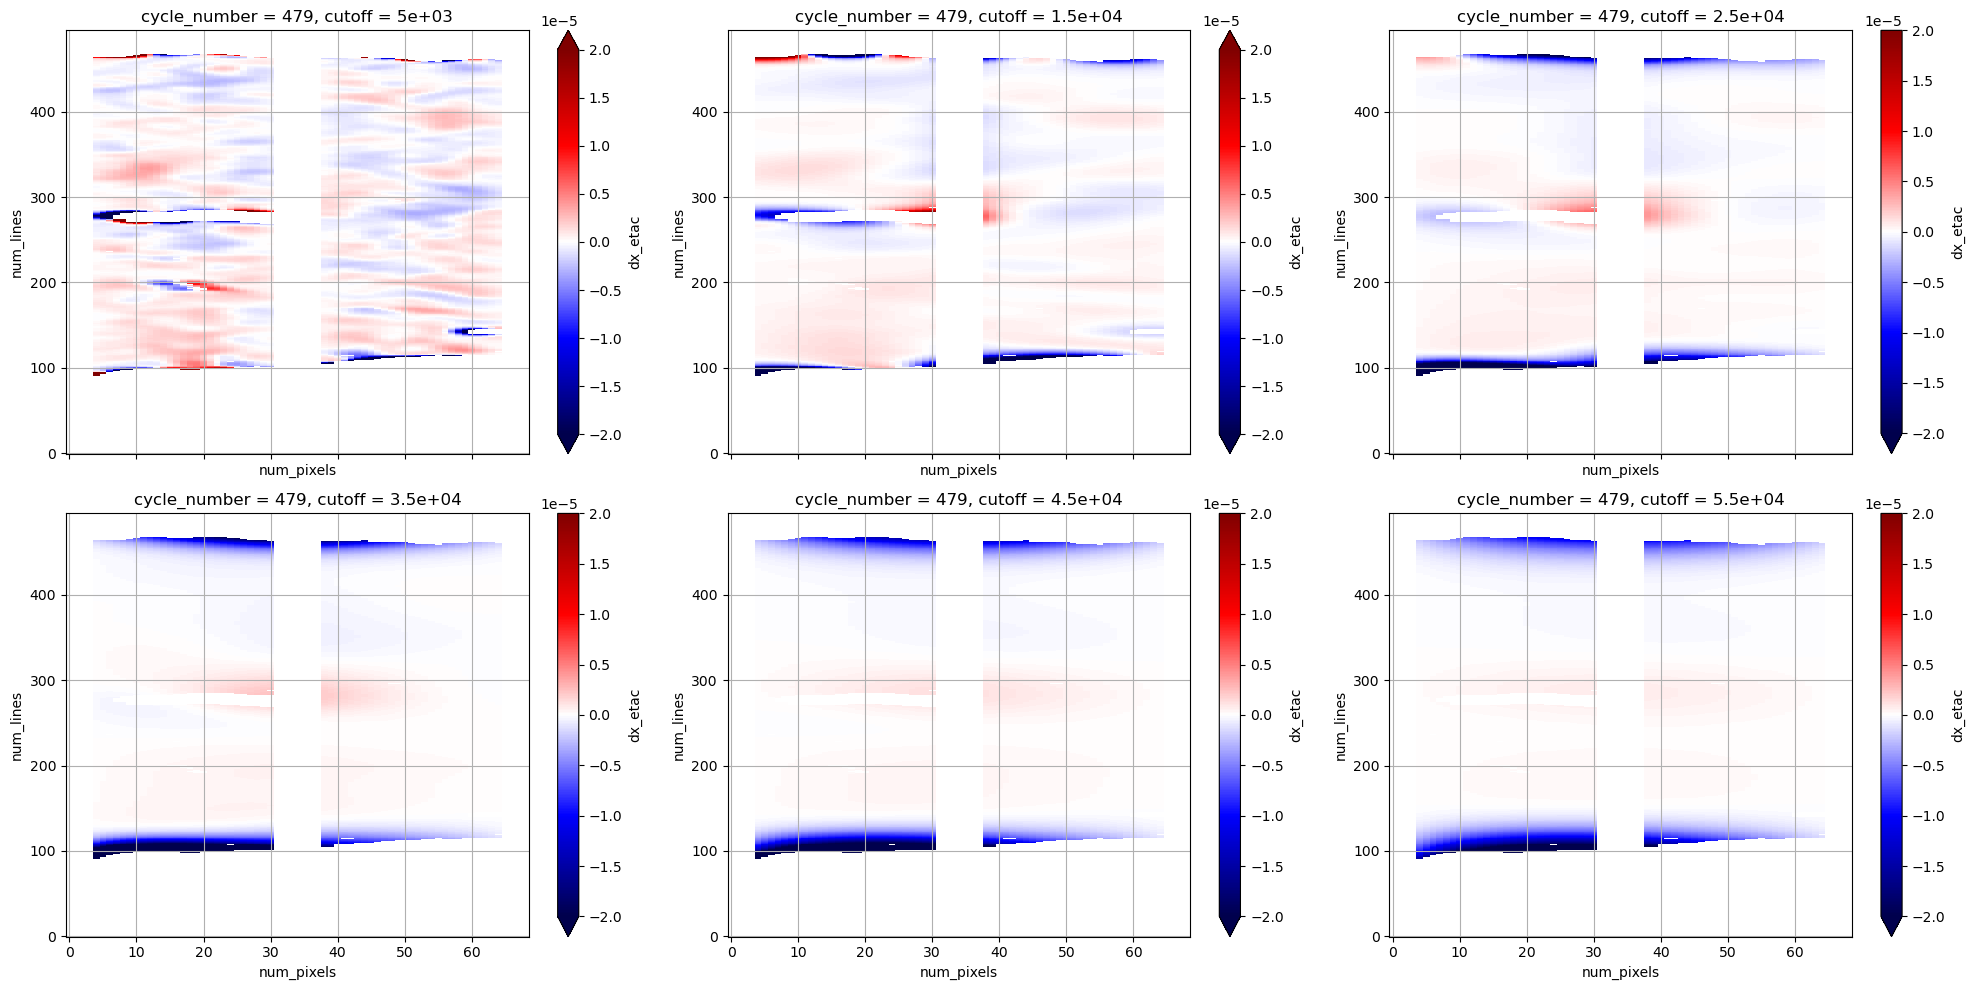

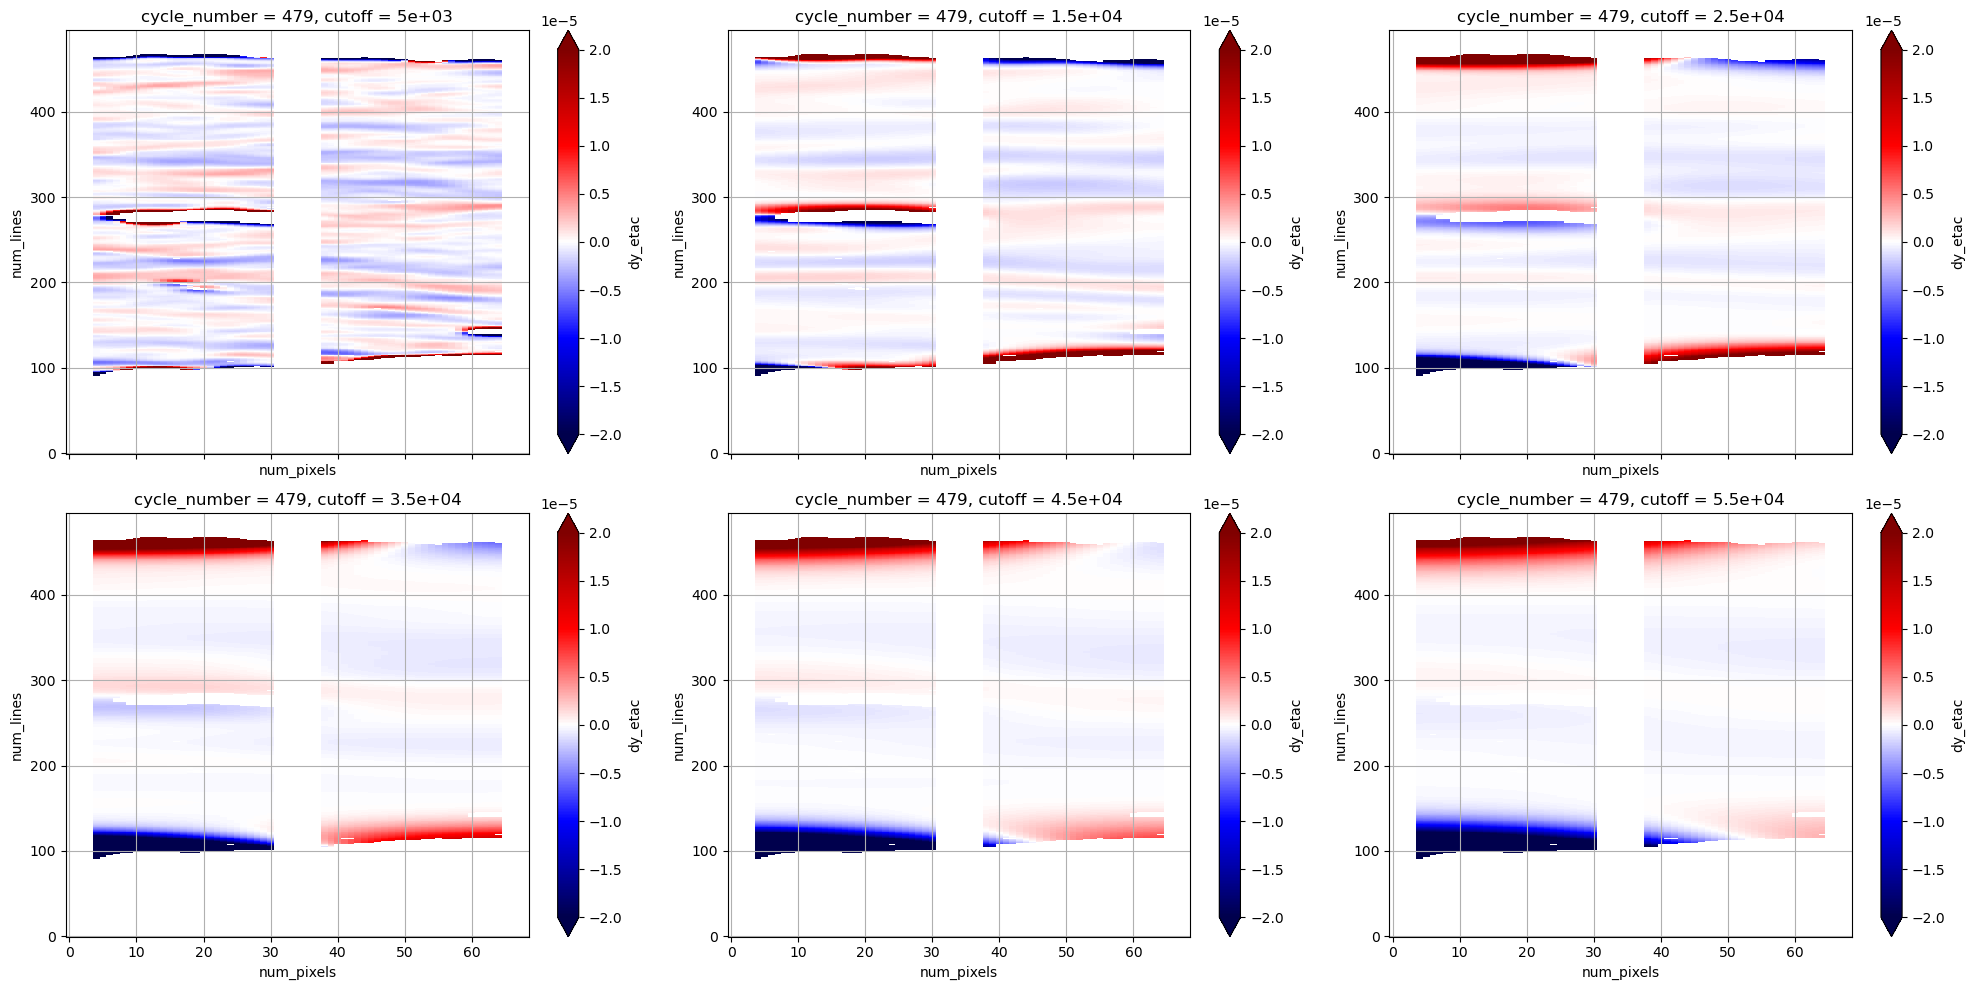

In [89]:
kwargs = {"vmin": -2e-5, "vmax": 2e-5, "cmap": "seismic"}

fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for i in range(len(ds.cutoff)):
    ds.isel(cutoff=i, cycle_number=1).dx_etac.plot(ax=axs[i], **kwargs)
for ax in axs:
    ax.grid()
fig.tight_layout()

fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for i in range(len(ds.cutoff)):
    ds.isel(cutoff=i, cycle_number=1).dy_etac.plot(ax=axs[i], **kwargs)
for ax in axs:
    ax.grid()
fig.tight_layout()

# Removing the 5 km near the coast before applying gaussian filtering

In [2]:
from altimetry_filter import compute_filter_diff

product = "swot2km"
method = "gaussian"
Cutoff = np.arange(5e3, 56e3, 10e3)
if product == "swot2km":
    dfs = browse_swot_2km().reset_index()
DS = []
# Gaussian
from cstes import zarr_dir

for pass_ in [3]:
    df = dfs[dfs.pass_number == pass_]
    ds_swot = df.set_index("cycle_number").iloc[0:10].to_xarray().persist()
    for cutoff in Cutoff:
        C = compute_filter_diff(
            ds_swot,
            filter_diff_method=method,
            filter_diff_kwargs={"cutoff": cutoff},
            mean_sla=False,
            distance_to_coast_max=5e3,
        ).compute()
        C["pass_number"] = pass_
        C["cutoff"] = xr.DataArray([cutoff], dims="cutoff")
        C = C.set_coords("cutoff")
        DS.append(C)
ds = xr.concat(DS, dim="cutoff")

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


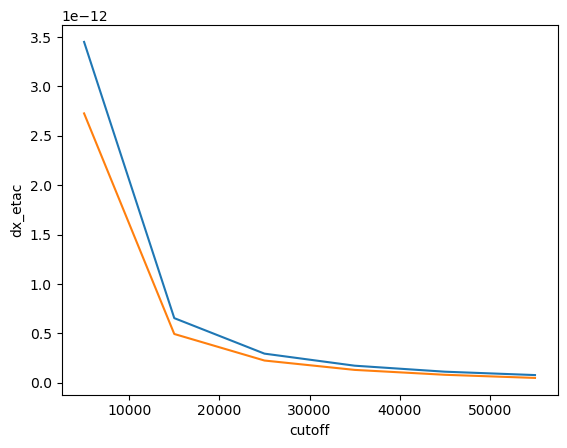

In [3]:
# ds.dx_etac.std(['cycle_number', 'num_lines', 'num_pixels']).plot()
(ds.dy_etac**2).mean(["cycle_number", "num_lines", "num_pixels"]).plot()
(ds.dx_etac**2).mean(["cycle_number", "num_lines", "num_pixels"]).plot()

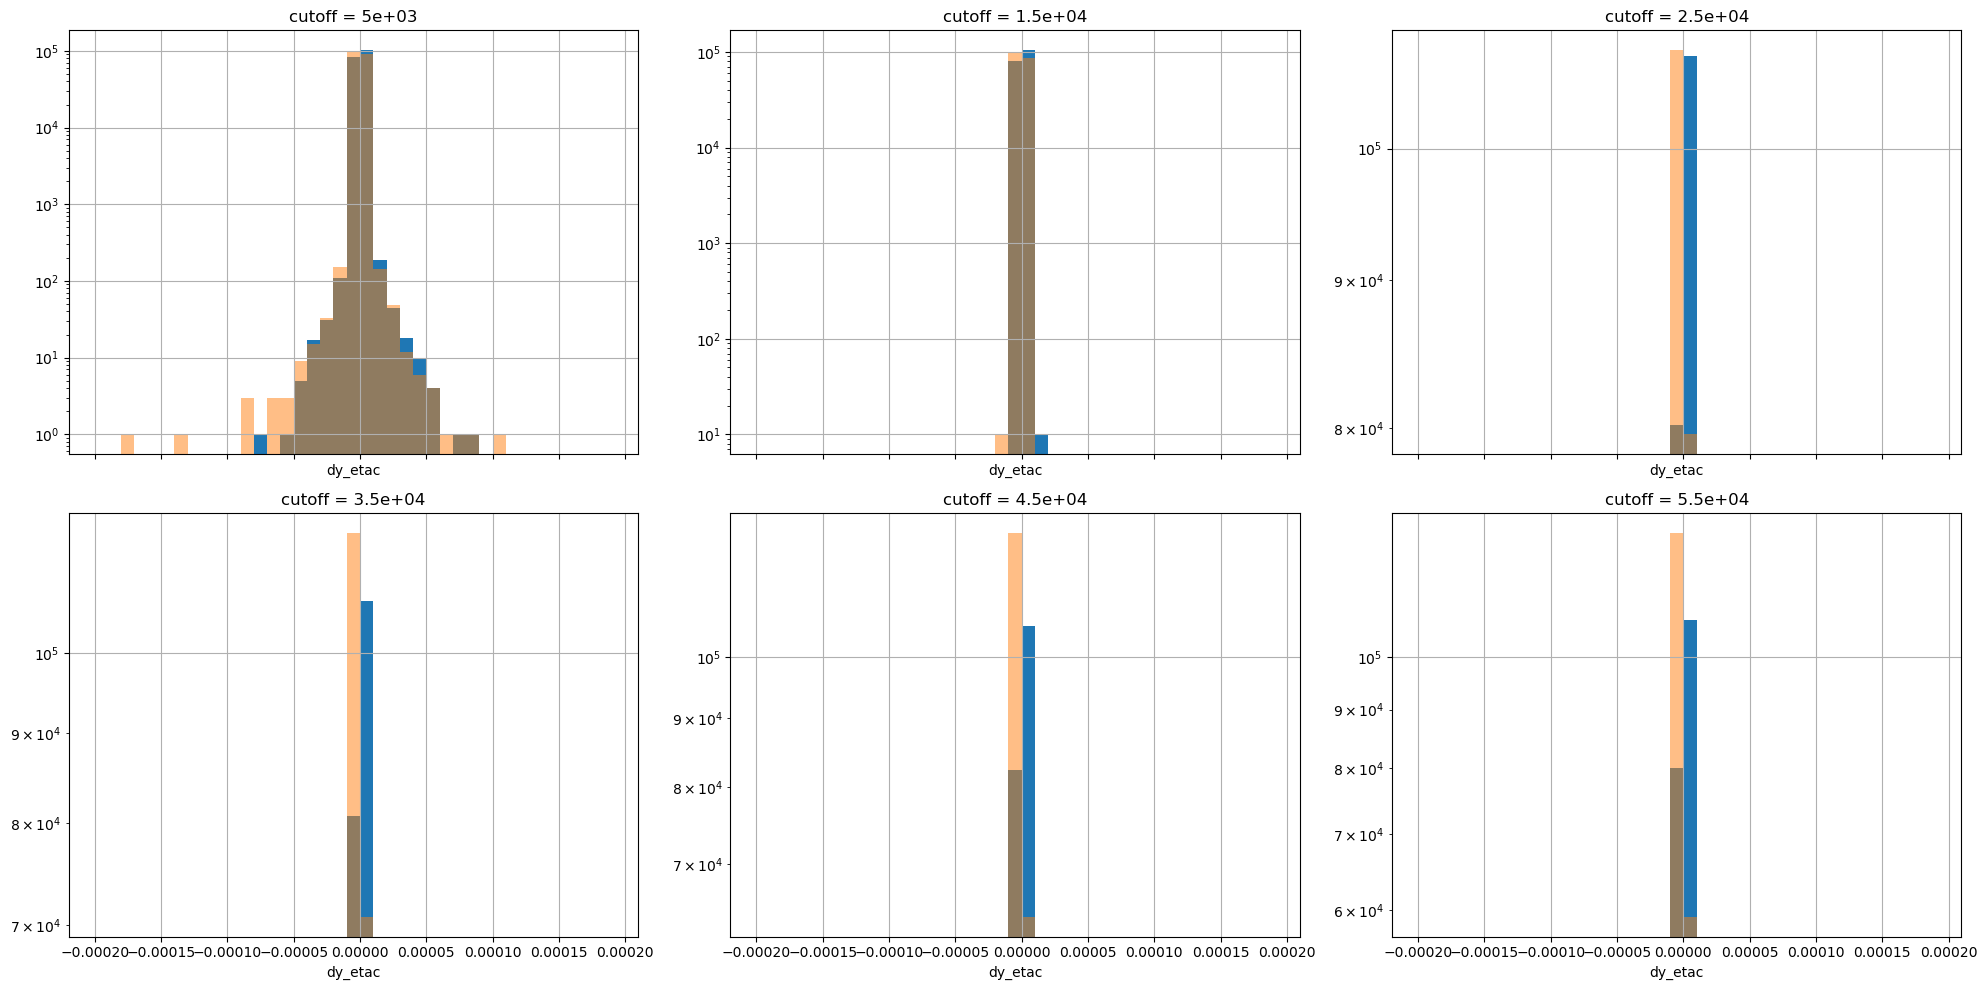

In [4]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for i in range(len(ds.cutoff)):
    ds.isel(cutoff=i).dx_etac.plot.hist(ax=axs[i], bins=np.arange(-2e-4, 2e-4, 1e-5))
    ds.isel(cutoff=i).dy_etac.plot.hist(
        ax=axs[i], bins=np.arange(-2e-4, 2e-4, 1e-5), alpha=0.5
    )
for ax in axs:
    ax.grid()
    ax.set_yscale("log")
fig.tight_layout()

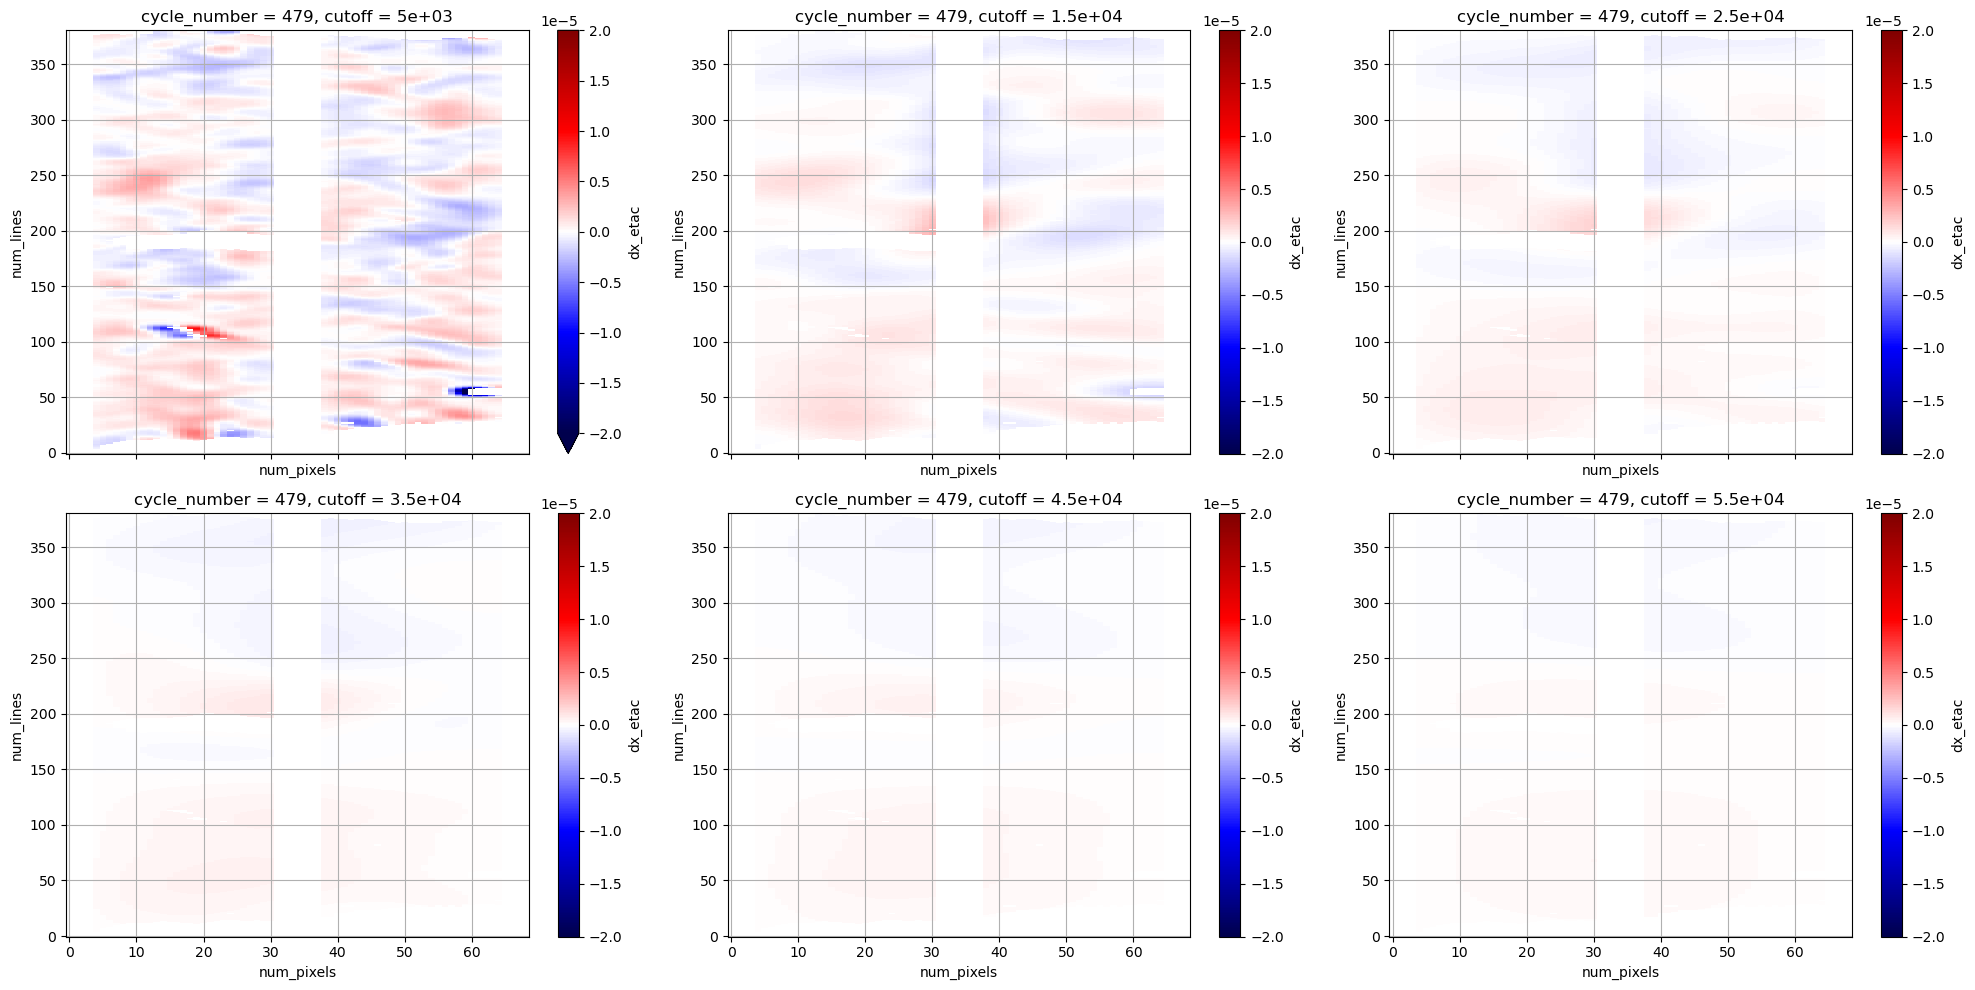

In [ ]:
kwargs = {"vmin": -2e-5, "vmax": 2e-5, "cmap": "seismic"}

fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for i in range(len(ds.cutoff)):
    ds.isel(cutoff=i, cycle_number=1).dx_etac.plot(ax=axs[i], **kwargs)
for ax in axs:
    ax.grid()
fig.tight_layout()

fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for i in range(len(ds.cutoff)):
    ds.isel(cutoff=i, cycle_number=1).dy_etac.plot(ax=axs[i], **kwargs)
for ax in axs:
    ax.grid()
fig.tight_layout()